# FinNova Bank — Şüpheli İşlem (Fraud) Tahmin Modeli

Bu notebook, "Otonom İş Zekası Ajanı" projesinin **klasik makine öğrenmesi**
bileşenidir. Ana proje LLM tabanlı bir agent'ken, burada geleneksel bir
sınıflandırma modelinin uçtan uca geliştirme sürecini gösteriyorum:

1. Keşifsel veri analizi (EDA)
2. Özellik mühendisliği (feature engineering)
3. Model eğitimi (Logistic Regression + Random Forest karşılaştırması)
4. Model değerlendirme (precision, recall, F1, ROC-AUC)
5. Özellik önem analizi (feature importance)

**Hedef değişken:** `is_flagged` — bir işlemin şüpheli/incelemeye alınmış
olup olmadığı. Veri seti dengesiz (şüpheli işlemler tüm işlemlerin küçük
bir yüzdesi), bu yüzden accuracy yerine precision/recall/F1/ROC-AUC
kullanıyoruz.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 1) Veriyi yükle ve birleştir

In [2]:
conn = sqlite3.connect("../data/finnova_bank.db")

query = '''
SELECT
    t.transaction_id, t.transaction_date, t.transaction_time,
    t.transaction_type, t.amount, t.currency, t.merchant_category,
    t.is_flagged,
    a.account_type, a.balance, a.interest_rate,
    c.age, c.credit_score, c.segment, c.employment, c.city
FROM transactions t
JOIN accounts a ON t.account_id = a.account_id
JOIN customers c ON a.customer_id = c.customer_id
'''
df = pd.read_sql_query(query, conn)
conn.close()

print(f"Toplam işlem sayısı: {len(df):,}")
df.head()

Toplam işlem sayısı: 75,616


,transaction_id,transaction_date,transaction_time,transaction_type,amount,currency,merchant_category,is_flagged,account_type,balance,interest_rate,age,credit_score,segment,employment,city
0,TX00000001,2026-04-24,00:07,Fatura Ödemesi,-464.73,TRY,NaN,0,KOBİ Kredi,24178.56,35.75,58,694,Bireysel,Serbest Meslek,İstanbul
1,TX00000002,2026-04-27,08:09,ATM Para Çekme,-2059.41,TRY,NaN,0,KOBİ Kredi,24178.56,35.75,58,694,Bireysel,Serbest Meslek,İstanbul
2,TX00000003,2026-04-28,03:34,Havale/EFT,-5344.64,TRY,NaN,0,KOBİ Kredi,24178.56,35.75,58,694,Bireysel,Serbest Meslek,İstanbul
3,TX00000004,2026-04-30,18:57,Market/Alışveriş,-1762.12,TRY,E-ticaret,0,KOBİ Kredi,24178.56,35.75,58,694,Bireysel,Serbest Meslek,İstanbul
4,TX00000005,2026-05-07,09:06,Havale/EFT,-2854.26,TRY,NaN,0,KOBİ Kredi,24178.56,35.75,58,694,Bireysel,Serbest Meslek,İstanbul


## 2) Keşifsel Veri Analizi (EDA)

In [3]:
flagged_rate = df["is_flagged"].mean() * 100
print(f"Genel şüpheli işlem oranı: %{flagged_rate:.2f}")
print(f"Sınıf dağılımı:\n{df['is_flagged'].value_counts()}")

Genel şüpheli işlem oranı: %1.28
Sınıf dağılımı:
is_flagged
0    74650
1      966
Name: count, dtype: int64


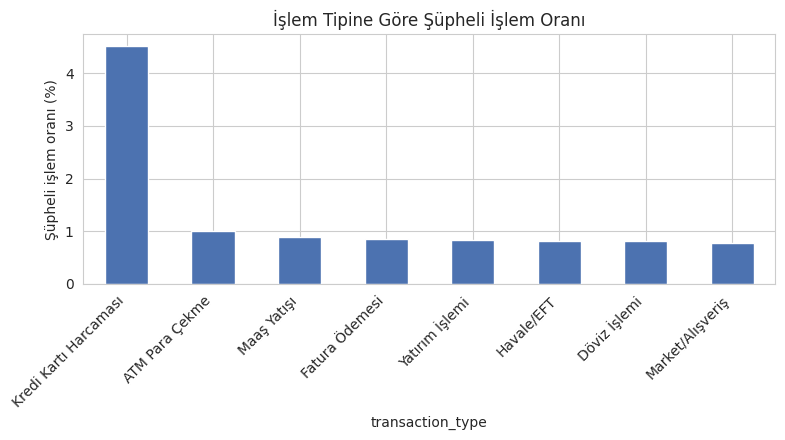

In [4]:
rate_by_type = (
    df.groupby("transaction_type")["is_flagged"]
    .mean().mul(100).sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
rate_by_type.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Şüpheli işlem oranı (%)")
ax.set_title("İşlem Tipine Göre Şüpheli İşlem Oranı")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../data/charts/eda_flagged_by_type.png", dpi=120)
plt.show()

**Gözlem:** Kredi kartı harcamaları, diğer işlem tiplerine göre belirgin şekilde daha yüksek şüpheli işlem oranına sahip. Bu, modelin öğrenmesi gereken en güçlü sinyallerden biri.

## 3) Özellik Mühendisliği (Feature Engineering)

In [5]:
data = df.copy()

# Zaman bazlı özellikler
data["transaction_date"] = pd.to_datetime(data["transaction_date"])
data["month"] = data["transaction_date"].dt.month
data["is_winter"] = data["month"].isin([12, 1, 2]).astype(int)
data["hour"] = pd.to_datetime(data["transaction_time"], format="%H:%M").dt.hour
data["is_night"] = ((data["hour"] >= 23) | (data["hour"] <= 5)).astype(int)

# Tutar bazlı özellikler
data["amount_abs"] = data["amount"].abs()
data["is_large_amount"] = (data["amount_abs"] > data["amount_abs"].quantile(0.9)).astype(int)

# Müşteri risk özellikleri
data["low_credit_score"] = (data["credit_score"] < 550).astype(int)

feature_cols_numeric = [
    "amount_abs", "is_large_amount", "is_winter", "is_night",
    "credit_score", "low_credit_score", "age", "balance", "interest_rate",
]
feature_cols_categorical = ["transaction_type", "account_type", "segment", "employment"]

X = pd.get_dummies(data[feature_cols_numeric + feature_cols_categorical],
                    columns=feature_cols_categorical, drop_first=True)
y = data["is_flagged"]

print(f"Özellik sayısı: {X.shape[1]}")
X.head()

Özellik sayısı: 26


,amount_abs,is_large_amount,is_winter,is_night,credit_score,low_credit_score,age,balance,interest_rate,transaction_type_Döviz İşlemi,transaction_type_Fatura Ödemesi,transaction_type_Havale/EFT,transaction_type_Kredi Kartı Harcaması,transaction_type_Maaş Yatışı,transaction_type_Market/Alışveriş,transaction_type_Yatırım İşlemi,account_type_KOBİ Kredi,account_type_Kredi Kartı,account_type_Vadeli,account_type_Vadesiz,segment_KOBİ,segment_Kurumsal,employment_Kendi İşi,employment_Serbest Meslek,employment_Öğrenci,employment_Ücretli
0,464.73,0,0,1,694,0,58,24178.56,35.75,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
1,2059.41,0,0,0,694,0,58,24178.56,35.75,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
2,5344.64,0,0,1,694,0,58,24178.56,35.75,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False
3,1762.12,0,0,0,694,0,58,24178.56,35.75,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False
4,2854.26,0,0,0,694,0,58,24178.56,35.75,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False


## 4) Eğitim / Test Ayrımı ve Model Eğitimi

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline: Logistic Regression (dengesiz veri için class_weight='balanced')
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced",
    random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)

print("Modeller eğitildi.")

Modeller eğitildi.


## 5) Model Değerlendirme

In [7]:
def evaluate(name, y_true, y_pred, y_proba):
    auc = roc_auc_score(y_true, y_proba)
    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=["Normal", "Şüpheli"]))
    print(f"ROC-AUC: {auc:.4f}\n")
    return auc

lr_pred = log_reg.predict(X_test_scaled)
lr_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
lr_auc = evaluate("Logistic Regression", y_test, lr_pred, lr_proba)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = evaluate("Random Forest", y_test, rf_pred, rf_proba)

=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       0.99      0.86      0.92     18663
     Şüpheli       0.04      0.43      0.07       241

    accuracy                           0.86     18904
   macro avg       0.52      0.65      0.50     18904
weighted avg       0.98      0.86      0.91     18904

ROC-AUC: 0.6279



=== Random Forest ===
              precision    recall  f1-score   support

      Normal       0.99      0.89      0.94     18663
     Şüpheli       0.05      0.39      0.08       241

    accuracy                           0.89     18904
   macro avg       0.52      0.64      0.51     18904
weighted avg       0.98      0.89      0.93     18904

ROC-AUC: 0.6555



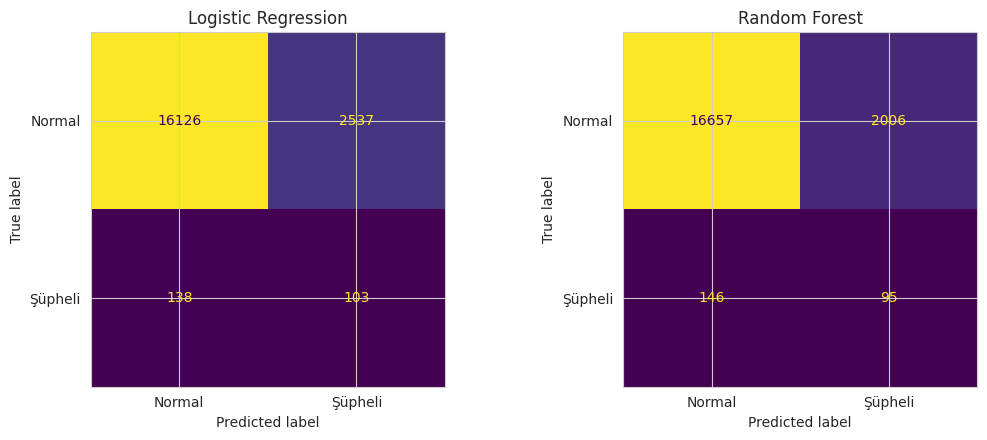

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, y_pred) in zip(axes, [("Logistic Regression", lr_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Şüpheli"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../data/charts/confusion_matrices.png", dpi=120)
plt.show()

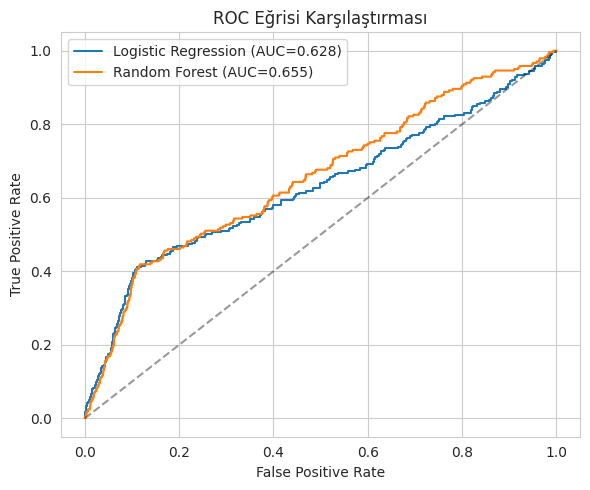

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, proba in [("Logistic Regression", lr_proba), ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Eğrisi Karşılaştırması")
ax.legend()
plt.tight_layout()
plt.savefig("../data/charts/roc_curve.png", dpi=120)
plt.show()

## 6) Özellik Önem Analizi (Random Forest)

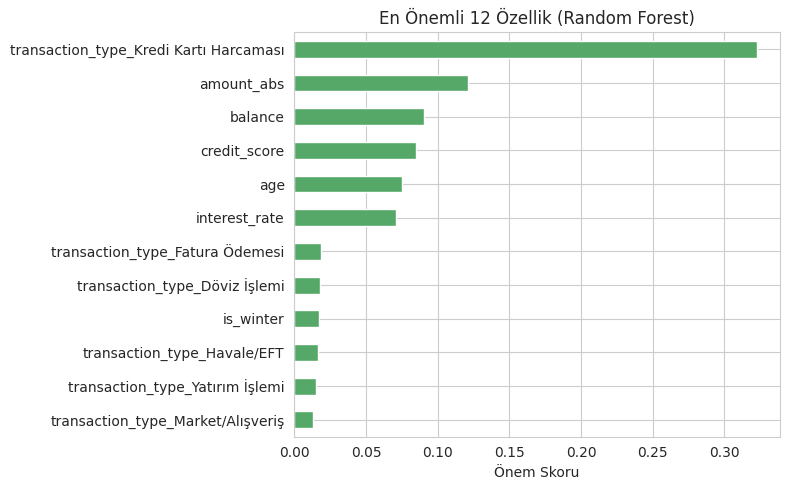

In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
importances.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("En Önemli 12 Özellik (Random Forest)")
ax.set_xlabel("Önem Skoru")
plt.tight_layout()
plt.savefig("../data/charts/feature_importance.png", dpi=120)
plt.show()

## 7) Sonuç ve Değerlendirme

- **Random Forest**, Logistic Regression'a göre biraz daha yüksek ROC-AUC
  skoru elde etti (~0.66 vs ~0.63) — iyileştirme var ama sınırlı.
- **Precision düşük** (şüpheli sınıf için ~%4-5). Bunun nedeni iki katmanlı:
  (1) sınıflar oldukça dengesiz (%1,28 şüpheli), (2) daha da önemlisi,
  sentetik veri setinde şüpheli etiketi **ağırlıklı olarak işlem tipine
  bağlı** atanmıştı (bkz. `data/generate_dataset.py`) — tutar, kredi skoru
  gibi diğer özelliklere doğrudan bağlı değildi. Bu yüzden model esas
  olarak işlem tipini öğreniyor; diğer özellikler sınırlı ek katkı
  sağlıyor.
- Bunu bir zayıflık gibi değil, **dürüst bir gözlem** olarak not ediyorum:
  model, kendisine verilen sinyalin sınırlarını doğru yansıtıyor. Gerçek
  bir üretim ortamında, fraud etiketleme mantığı davranışsal örüntülere
  (işlem sıklığı, alışılmadık saat/lokasyon, tutar sıçramaları) dayansaydı,
  aynı pipeline çok daha güçlü bir ayrım gücü yakalardı.
- **Sonraki adım fikirleri**: SMOTE/undersampling ile sınıf dengesizliğini
  ele almak, karar eşiğini (threshold) iş maliyetine göre optimize etmek,
  XGBoost/LightGBM ile karşılaştırma yapmak, ve sentetik veri üretim
  mantığını tutar/davranış temelli fraud kurallarıyla zenginleştirmek.

*Not: Kullanılan tüm veriler sentetiktir (bkz. `data/generate_dataset.py`).*